# Notebook 26 — Plating Full Fingerprint Audit

## Goal

This notebook extends Notebook 25 from plating entry observability（析锂入口可观测性） to a full mechanism-fingerprint audit for lithium plating（析锂）.

Notebook 25 established that SEI-background partially reversible lithium plating is runnable and directly observable in OKane2022. It also showed that matched no-plating controls are required because temperature and stress-charge rate affect post-protocol capacity.

Notebook 26 now asks:

> Does lithium plating produce a diagnostic fingerprint that is separable from SEI-only aging, contact / ohmic resistance growth, and LAM?

## Scientific context

Previous mechanism branches established:

- SEI-only aging（SEI 单机制老化）: capacity-dominant, voltage-secondary, derivative auxiliary.
- Contact / ohmic resistance growth（接触/欧姆阻抗增长）: Ri(t)-dominant, post-ohmic relaxation invariant, capacity-weak.
- LAM（Loss of Active Material，活性材料损失）: capacity- and voltage-shape-sensitive, DVA-informative.
- Plating entry（析锂入口）: direct plating variables observable, full fingerprint deferred.

## Mechanism Fingerprint Registry v0.2

This notebook uses the same registry:

- `capacity_RPT`
- `Ri_0.05s`
- `Ri_0.1s`
- `Ri_1s`
- `Ri_10s`
- `Ri_recovery_0.1s`
- `Ri_recovery_1s`
- `tau_FG_eff`
- `t95`
- `t99`
- `tau_tail`
- `recovery_amplitude`
- `recovery_area`
- `C25_central_VQ`
- `GITT_finite_rest`
- `ICA_DVA_central`
- `endpoint_boundary`
- `best_fitting_targets`
- `rejection_flags`

## Study design

The notebook builds post-stress states using the supported Notebook 25 protocol:

- initial SOC = 0.05,
- charge to 4.2 V at stress-charge rate,
- hold at 4.2 V until C/20,
- rest for 60 min.

Matched conditions:

- no_plating_25C_1C vs plating_25C_1C,
- no_plating_10C_1C vs plating_10C_1C,
- no_plating_10C_2C vs plating_10C_2C.

From each post-stress state, downstream diagnostic branches can be run:

1. Capacity RPT（容量基准性能测试）,
2. HPPC Ri(t)（时间窗内阻）,
3. corrected relaxation descriptors（修正后恢复描述符）,
4. C/25 OCV-like V(Q)（C/25 近似 OCV 电压曲线）,
5. GITT-like finite-rest voltage（GITT-like 有限静置电压）,
6. ICA/DVA central features（中央窗口微分电压特征）.

## Phase A scope

This first phase runs:

1. post-stress state generation,
2. direct plating-state observability audit,
3. Capacity RPT from post-stress state,
4. matched capacity-effect audit.

HPPC, C/25, GITT, and ICA/DVA are deferred until Phase A confirms the post-stress state and capacity layer are clean.

## Interpretation boundary

This notebook must preserve matched-control interpretation.

A plating-enabled branch must be compared only against its matched no-plating branch at the same temperature and stress-charge rate.

Direct plating variables must not be equated with final irreversible capacity loss, especially under partially reversible plating.

In [1]:
# Cell 1 — Imports, paths, and environment check（导入依赖、路径与环境检查）

from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("[ENV] PyBaMM:", pybamm.__version__)
print("[ENV] Repository:", REPO)
print("[ENV] Data dir:", DATA)
print("[ENV] Figures dir:", FIGURES)

assert pybamm.__version__ == "26.3.1", "Expected PyBaMM 26.3.1 for this project."
assert REPO.exists(), f"Repository path does not exist: {REPO}"

print("[OK] Environment check passed.")

[ENV] PyBaMM: 26.3.1
[ENV] Repository: /Users/louislu/projects/pybamm-aging-bridge
[ENV] Data dir: /Users/louislu/projects/pybamm-aging-bridge/data
[ENV] Figures dir: /Users/louislu/projects/pybamm-aging-bridge/figures
[OK] Environment check passed.


In [2]:
# Cell 2 — Registry v0.2 and full plating matched-condition contract
# （注册表 v0.2 与完整析锂匹配条件合同）

registry_path = DATA / "mechanism_fingerprint_registry_v0_2.csv"

if registry_path.exists():
    fingerprint_registry_v02 = pd.read_csv(registry_path)
    print(f"[OK] loaded registry: {registry_path}")
else:
    raise FileNotFoundError(
        "Mechanism Fingerprint Registry v0.2 not found. "
        "Run Notebook 23 first or restore mechanism_fingerprint_registry_v0_2.csv."
    )

display(fingerprint_registry_v02)

PLATING_FULL_CONTRACT = pd.DataFrame([
    {
        "pair": "25C_1C",
        "condition": "no_plating_25C_1C",
        "plating_mode": "none",
        "temperature_C": 25.0,
        "stress_charge_rate": "1C",
        "initial_soc": 0.05,
        "role": "matched no-plating control",
    },
    {
        "pair": "25C_1C",
        "condition": "plating_25C_1C",
        "plating_mode": "partially reversible",
        "temperature_C": 25.0,
        "stress_charge_rate": "1C",
        "initial_soc": 0.05,
        "role": "plating-enabled condition",
    },
    {
        "pair": "10C_1C",
        "condition": "no_plating_10C_1C",
        "plating_mode": "none",
        "temperature_C": 10.0,
        "stress_charge_rate": "1C",
        "initial_soc": 0.05,
        "role": "matched no-plating control",
    },
    {
        "pair": "10C_1C",
        "condition": "plating_10C_1C",
        "plating_mode": "partially reversible",
        "temperature_C": 10.0,
        "stress_charge_rate": "1C",
        "initial_soc": 0.05,
        "role": "plating-enabled condition",
    },
    {
        "pair": "10C_2C",
        "condition": "no_plating_10C_2C",
        "plating_mode": "none",
        "temperature_C": 10.0,
        "stress_charge_rate": "2C",
        "initial_soc": 0.05,
        "role": "matched no-plating control",
    },
    {
        "pair": "10C_2C",
        "condition": "plating_10C_2C",
        "plating_mode": "partially reversible",
        "temperature_C": 10.0,
        "stress_charge_rate": "2C",
        "initial_soc": 0.05,
        "role": "plating-enabled condition",
    },
])

contract_path = DATA / "plating_full_branch_contract.csv"
PLATING_FULL_CONTRACT.to_csv(contract_path, index=False)

print(f"[OK] saved: {contract_path}")
display(PLATING_FULL_CONTRACT)

[OK] loaded registry: /Users/louislu/projects/pybamm-aging-bridge/data/mechanism_fingerprint_registry_v0_2.csv


,metric_layer,description,primary_use,risk
0,capacity_RPT,External discharge capacity / capacity fade fr...,primary fitting target for capacity-loss mecha...,voltage cutoff can mix true capacity loss with...
1,Ri_0.05s,Pulse-on resistance at 50 ms,ohmic / very-fast polarization target,trigger and sampling-window sensitive
2,Ri_0.1s,Pulse-on resistance at 100 ms,ohmic / fast polarization target,still partly sensitive to pulse detection and ...
3,Ri_1s,Pulse-on resistance at 1 s,fast-to-medium polarization response,already includes non-ohmic transient contribution
4,Ri_10s,Pulse-on resistance near pulse end at 10 s,slow polarization / diffusion-sensitive resist...,strongly time-window dependent
5,Ri_recovery_0.1s,Pulse-off recovery resistance at 100 ms after ...,current-off ohmic / fast recovery descriptor,sensitive to pulse-off timing
6,Ri_recovery_1s,Pulse-off recovery resistance at 1 s after cur...,short recovery descriptor,mixes ohmic and early relaxation response
7,tau_FG_eff,Effective 63.2% voltage-recovery time after pu...,secondary relaxation descriptor,depends on U_inf and relaxation window
8,t95,Time to reach 95% of finite-window recovery am...,relaxation completion descriptor,sensitive to final-voltage definition
9,t99,Time to reach 99% of finite-window recovery am...,slow-tail recovery descriptor,sensitive to numerical floor and U_inf drift


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_full_branch_contract.csv


,pair,condition,plating_mode,temperature_C,stress_charge_rate,initial_soc,role
0,25C_1C,no_plating_25C_1C,none,25.0,1C,0.05,matched no-plating control
1,25C_1C,plating_25C_1C,partially reversible,25.0,1C,0.05,plating-enabled condition
2,10C_1C,no_plating_10C_1C,none,10.0,1C,0.05,matched no-plating control
3,10C_1C,plating_10C_1C,partially reversible,10.0,1C,0.05,plating-enabled condition
4,10C_2C,no_plating_10C_2C,none,10.0,2C,0.05,matched no-plating control
5,10C_2C,plating_10C_2C,partially reversible,10.0,2C,0.05,plating-enabled condition


## Methodological boundary before execution

Notebook 26 starts from post-stress states, not from a fully discharged or fully aged state.

Each plating-enabled condition must be compared against its matched no-plating control at the same temperature and stress-charge rate.

The key distinction is:

- direct plating variables（直接析锂变量） measure plated-lithium state or plating reaction activity;
- downstream diagnostics（后续诊断） measure how that post-stress state appears through capacity, Ri(t), relaxation, V(Q), GITT, or ICA/DVA.

These are related but not identical.

In [3]:
# Cell 3 — SEI-background OKane2022 plating model builder
# （带 SEI 背景的 OKane2022 析锂模型构建）

def build_plating_model(plating_mode="partially reversible", temperature_C=25.0):
    """
    Build OKane2022 DFN with lithium plating option.

    Important:
    OKane2022 partially reversible plating（部分可逆析锂）depends on SEI thickness（SEI 厚度）
    through dead-lithium decay, so SEI must be enabled.
    """
    options = {
        "SEI": "solvent-diffusion limited",
        "SEI porosity change": "false",
        "lithium plating": plating_mode,
        "lithium plating porosity change": "false",
        "loss of active material": "none",
        "particle mechanics": "none",
        "thermal": "isothermal",
    }

    model = pybamm.lithium_ion.DFN(options=options)
    parameter_values = pybamm.ParameterValues("OKane2022")

    temperature_K = temperature_C + 273.15

    parameter_values.update(
        {
            "Ambient temperature [K]": temperature_K,
            "Initial temperature [K]": temperature_K,
        },
        check_already_exists=False,
    )

    return model, parameter_values


def make_solver():
    return pybamm.CasadiSolver(
        mode="safe",
        atol=1e-6,
        rtol=1e-6,
        dt_max=600,
    )


for _, r in PLATING_FULL_CONTRACT.iterrows():
    model, pv = build_plating_model(
        plating_mode=r["plating_mode"],
        temperature_C=float(r["temperature_C"]),
    )
    print(
        f"[OK] model built: {r['condition']} | "
        f"SEI=solvent-diffusion limited | "
        f"plating={r['plating_mode']} | "
        f"T={r['temperature_C']} °C"
    )

print("[OK] SEI-background plating model builder smoke test passed.")

[OK] model built: no_plating_25C_1C | SEI=solvent-diffusion limited | plating=none | T=25.0 °C
[OK] model built: plating_25C_1C | SEI=solvent-diffusion limited | plating=partially reversible | T=25.0 °C
[OK] model built: no_plating_10C_1C | SEI=solvent-diffusion limited | plating=none | T=10.0 °C
[OK] model built: plating_10C_1C | SEI=solvent-diffusion limited | plating=partially reversible | T=10.0 °C
[OK] model built: no_plating_10C_2C | SEI=solvent-diffusion limited | plating=none | T=10.0 °C
[OK] model built: plating_10C_2C | SEI=solvent-diffusion limited | plating=partially reversible | T=10.0 °C
[OK] SEI-background plating model builder smoke test passed.


In [4]:
# Cell 4 — Plating full-fingerprint protocol constants
# （析锂完整指纹协议常数）

STRESS_PERIOD = "10 seconds"

def make_plating_stress_state_protocol(stress_charge_rate="1C"):
    """
    Build post-stress state protocol.

    This stops after charge + CV + rest.
    The downstream diagnostics branch from this state.
    """
    return [
        f"Charge at {stress_charge_rate} until 4.2 V",
        "Hold at 4.2 V until C/20",
        "Rest for 60 minutes",
    ]


CAPACITY_RPT_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 60 minutes",
]
CAPACITY_RPT_PERIOD = "60 seconds"

# Future branches are defined now but not all executed in Phase A.
HPPC_STEPS = [
    "Discharge at C/3 for 90 minutes",
    "Rest for 60 minutes",
    "Discharge at 1C for 10 seconds",
    "Rest for 600 seconds",
]
HPPC_PERIOD = "0.1 seconds"

C25_OCV_STEPS = [
    "Discharge at C/25 until 2.5 V",
    "Rest for 60 minutes",
]
C25_OCV_PERIOD = "60 seconds"

print("[CONFIG] stress-state protocol examples:")
for rate in ["1C", "2C"]:
    print(rate, ":", make_plating_stress_state_protocol(rate))

print("[CONFIG] Capacity RPT:", CAPACITY_RPT_STEPS)
print("[CONFIG] HPPC:", HPPC_STEPS)
print("[CONFIG] C/25:", C25_OCV_STEPS)

print("[OK] Protocol constants defined.")

[CONFIG] stress-state protocol examples:
1C : ['Charge at 1C until 4.2 V', 'Hold at 4.2 V until C/20', 'Rest for 60 minutes']
2C : ['Charge at 2C until 4.2 V', 'Hold at 4.2 V until C/20', 'Rest for 60 minutes']
[CONFIG] Capacity RPT: ['Discharge at C/3 until 2.5 V', 'Rest for 60 minutes']
[CONFIG] HPPC: ['Discharge at C/3 for 90 minutes', 'Rest for 60 minutes', 'Discharge at 1C for 10 seconds', 'Rest for 600 seconds']
[CONFIG] C/25: ['Discharge at C/25 until 2.5 V', 'Rest for 60 minutes']
[OK] Protocol constants defined.


In [5]:
# Cell 5 — Run matched plating post-stress states
# （运行匹配析锂应力后状态）

def run_plating_condition_experiment(row, steps, period, starting_solution=None):
    condition = row["condition"]
    plating_mode = row["plating_mode"]
    temperature_C = float(row["temperature_C"])
    initial_soc = float(row["initial_soc"])

    model, pv = build_plating_model(
        plating_mode=plating_mode,
        temperature_C=temperature_C,
    )

    experiment = pybamm.Experiment(steps, period=period)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    else:
        kwargs["initial_soc"] = initial_soc

    print(
        f"[RUN] {condition} | plating={plating_mode} | "
        f"T={temperature_C} °C | stress={row['stress_charge_rate']}"
    )

    t0 = time.perf_counter()
    sol = sim.solve(**kwargs)
    elapsed = time.perf_counter() - t0

    print(f"[OK] solved: {condition} | runtime={elapsed:.1f} s")
    return sol


post_stress_solutions = {}

for _, row in PLATING_FULL_CONTRACT.iterrows():
    steps = make_plating_stress_state_protocol(
        stress_charge_rate=row["stress_charge_rate"]
    )
    post_stress_solutions[row["condition"]] = run_plating_condition_experiment(
        row=row,
        steps=steps,
        period=STRESS_PERIOD,
        starting_solution=None,
    )

print("[OK] All post-stress states solved.")
print("[N post-stress solutions]", len(post_stress_solutions))

[RUN] no_plating_25C_1C | plating=none | T=25.0 °C | stress=1C
[OK] solved: no_plating_25C_1C | runtime=0.8 s
[RUN] plating_25C_1C | plating=partially reversible | T=25.0 °C | stress=1C
[OK] solved: plating_25C_1C | runtime=0.9 s
[RUN] no_plating_10C_1C | plating=none | T=10.0 °C | stress=1C
[OK] solved: no_plating_10C_1C | runtime=0.9 s
[RUN] plating_10C_1C | plating=partially reversible | T=10.0 °C | stress=1C
[OK] solved: plating_10C_1C | runtime=0.9 s
[RUN] no_plating_10C_2C | plating=none | T=10.0 °C | stress=2C
[OK] solved: no_plating_10C_2C | runtime=1.0 s
[RUN] plating_10C_2C | plating=partially reversible | T=10.0 °C | stress=2C
[OK] solved: plating_10C_2C | runtime=1.1 s
[OK] All post-stress states solved.
[N post-stress solutions] 6


In [6]:
# Cell 6 — Post-stress direct plating-state audit
# （应力后直接析锂状态审计）

PLATING_VARIABLE_CANDIDATES = {
    "loss_of_capacity_to_plating_Ah": [
        "Loss of capacity to negative lithium plating [A.h]",
        "Loss of capacity to lithium plating [A.h]",
        "Loss of capacity to plated lithium [A.h]",
    ],
    "loss_of_lithium_to_plating_mol": [
        "Loss of lithium to negative lithium plating [mol]",
        "Loss of lithium to lithium plating [mol]",
        "Total lithium lost to lithium plating [mol]",
    ],
    "plated_lithium_concentration": [
        "X-averaged negative lithium plating concentration [mol.m-3]",
        "Volume-averaged negative lithium plating concentration [mol.m-3]",
        "Negative lithium plating concentration [mol.m-3]",
    ],
    "dead_lithium_concentration": [
        "X-averaged negative dead lithium concentration [mol.m-3]",
        "Volume-averaged negative dead lithium concentration [mol.m-3]",
        "Negative dead lithium concentration [mol.m-3]",
    ],
    "plated_lithium_thickness_m": [
        "X-averaged negative lithium plating thickness [m]",
        "Volume-averaged negative lithium plating thickness [m]",
        "Negative lithium plating thickness [m]",
    ],
    "dead_lithium_thickness_m": [
        "X-averaged negative dead lithium thickness [m]",
        "Volume-averaged negative dead lithium thickness [m]",
        "Negative dead lithium thickness [m]",
    ],
    "plating_current_density_A_m2": [
        "X-averaged negative electrode lithium plating interfacial current density [A.m-2]",
        "Negative electrode lithium plating interfacial current density [A.m-2]",
        "X-averaged negative lithium plating interfacial current density [A.m-2]",
        "Negative lithium plating interfacial current density [A.m-2]",
    ],
    "plating_overpotential_V": [
        "X-averaged negative electrode lithium plating reaction overpotential [V]",
        "Negative electrode lithium plating reaction overpotential [V]",
    ],
}


def _as_time_series(entries):
    arr = np.asarray(entries, dtype=float)
    if arr.ndim == 0:
        return np.array([float(arr)])
    if arr.ndim == 1:
        return arr
    spatial_axes = tuple(range(arr.ndim - 1))
    return np.nanmean(arr, axis=spatial_axes)


def get_variable_last_and_extrema(sol, candidates):
    for name in candidates:
        try:
            series = _as_time_series(sol[name].entries)
            return {
                "source": name,
                "last": float(series[-1]),
                "min": float(np.nanmin(series)),
                "max": float(np.nanmax(series)),
                "abs_max": float(np.nanmax(np.abs(series))),
                "n_points": int(len(series)),
            }
        except Exception:
            continue

    return {
        "source": None,
        "last": np.nan,
        "min": np.nan,
        "max": np.nan,
        "abs_max": np.nan,
        "n_points": 0,
    }


def extract_basic_protocol_observables(sol):
    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    u = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    t_h = (t - t[0]) / 3600.0
    q_signed_Ah = np.zeros_like(t_h)

    if len(t_h) > 1:
        dt_h = np.diff(t_h)
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_signed_Ah[1:] = np.cumsum(i_mid * dt_h)

    return {
        "t_end_h": float(t_h[-1]),
        "U_final_V": float(u[-1]),
        "I_final_A": float(i[-1]),
        "U_max_V": float(np.nanmax(u)),
        "U_min_V": float(np.nanmin(u)),
        "I_min_A": float(np.nanmin(i)),
        "I_max_A": float(np.nanmax(i)),
        "q_signed_final_Ah": float(q_signed_Ah[-1]),
        "q_signed_min_Ah": float(np.nanmin(q_signed_Ah)),
        "q_signed_max_Ah": float(np.nanmax(q_signed_Ah)),
    }


DIRECT_SIGNAL_COLUMNS = [
    "loss_of_capacity_to_plating_Ah_abs_max",
    "loss_of_lithium_to_plating_mol_abs_max",
    "plated_lithium_concentration_abs_max",
    "dead_lithium_concentration_abs_max",
    "plated_lithium_thickness_m_abs_max",
    "dead_lithium_thickness_m_abs_max",
    "plating_current_density_A_m2_abs_max",
]

post_stress_obs_rows = []

for _, row in PLATING_FULL_CONTRACT.iterrows():
    condition = row["condition"]
    sol = post_stress_solutions[condition]

    out = {
        "pair": row["pair"],
        "condition": condition,
        "plating_mode": row["plating_mode"],
        "temperature_C": float(row["temperature_C"]),
        "stress_charge_rate": row["stress_charge_rate"],
        "initial_soc": float(row["initial_soc"]),
        "role": row["role"],
    }

    out.update(extract_basic_protocol_observables(sol))

    for metric, candidates in PLATING_VARIABLE_CANDIDATES.items():
        v = get_variable_last_and_extrema(sol, candidates)
        out[f"{metric}_source"] = v["source"]
        out[f"{metric}_last"] = v["last"]
        out[f"{metric}_min"] = v["min"]
        out[f"{metric}_max"] = v["max"]
        out[f"{metric}_abs_max"] = v["abs_max"]
        out[f"{metric}_n_points"] = v["n_points"]

    post_stress_obs_rows.append(out)

post_stress_observability_table = pd.DataFrame(post_stress_obs_rows)

for col in DIRECT_SIGNAL_COLUMNS:
    if col not in post_stress_observability_table.columns:
        post_stress_observability_table[col] = np.nan

post_stress_observability_table["any_direct_plating_signal_nonzero"] = (
    post_stress_observability_table[DIRECT_SIGNAL_COLUMNS]
    .fillna(0.0)
    .abs()
    .max(axis=1)
    > 1e-14
)

obs_path = DATA / "plating_full_post_stress_observability_table.csv"
post_stress_observability_table.to_csv(obs_path, index=False)

print(f"[OK] saved: {obs_path}")

display_cols = [
    "pair", "condition", "plating_mode", "temperature_C", "stress_charge_rate",
    "t_end_h", "U_final_V", "I_min_A",
    "loss_of_capacity_to_plating_Ah_last",
    "loss_of_capacity_to_plating_Ah_abs_max",
    "loss_of_lithium_to_plating_mol_last",
    "loss_of_lithium_to_plating_mol_abs_max",
    "plated_lithium_thickness_m_abs_max",
    "dead_lithium_thickness_m_abs_max",
    "plating_current_density_A_m2_abs_max",
    "any_direct_plating_signal_nonzero",
]

display(post_stress_observability_table[[c for c in display_cols if c in post_stress_observability_table.columns]])

print("[OK] Post-stress direct plating-state audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_full_post_stress_observability_table.csv


,pair,condition,plating_mode,temperature_C,stress_charge_rate,t_end_h,U_final_V,I_min_A,loss_of_capacity_to_plating_Ah_last,loss_of_capacity_to_plating_Ah_abs_max,loss_of_lithium_to_plating_mol_last,loss_of_lithium_to_plating_mol_abs_max,plated_lithium_thickness_m_abs_max,dead_lithium_thickness_m_abs_max,plating_current_density_A_m2_abs_max,any_direct_plating_signal_nonzero
0,25C_1C,no_plating_25C_1C,none,25.0,1C,2.623741,4.172616,-5.000539,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,False
1,25C_1C,plating_25C_1C,partially reversible,25.0,1C,2.617941,4.171749,-5.000546,0.007979,0.044523,0.000298,0.001661,6.417975e-09,2.569716e-11,0.030974,True
2,10C_1C,no_plating_10C_1C,none,10.0,1C,3.076181,4.153906,-5.000483,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,False
3,10C_1C,plating_10C_1C,partially reversible,10.0,1C,3.059738,4.151808,-5.000493,0.006793,0.072795,0.000253,0.002716,1.048451e-08,5.514311e-11,0.057522,True
4,10C_2C,no_plating_10C_2C,none,10.0,2C,2.945358,4.152837,-10.000661,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,False
5,10C_2C,plating_10C_2C,partially reversible,10.0,2C,2.921711,4.150141,-10.000664,0.006904,0.095446,0.000258,0.003561,1.376115e-08,7.434650e-11,0.138783,True


[OK] Post-stress direct plating-state audit complete.


In [7]:
# Cell 7 — Capacity RPT from plating post-stress states
# （析锂应力后状态的容量基准性能测试）

def summarize_current_segments(sol, condition, eps=1e-5):
    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    u = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    state = np.where(i > eps, "discharge", np.where(i < -eps, "charge", "rest"))
    change_idx = np.r_[0, np.flatnonzero(state[1:] != state[:-1]) + 1, len(state)]

    rows = []
    for k in range(len(change_idx) - 1):
        a, b = change_idx[k], change_idx[k + 1]
        if b - a < 2:
            continue

        rows.append({
            "condition": condition,
            "segment_id": int(k),
            "segment_type": state[a],
            "idx_start": int(a),
            "idx_stop": int(b),
            "t_start_s": float(t[a]),
            "t_end_s": float(t[b - 1]),
            "duration_s": float(t[b - 1] - t[a]),
            "duration_min": float((t[b - 1] - t[a]) / 60),
            "U_start_V": float(u[a]),
            "U_end_V": float(u[b - 1]),
            "I_mean_A": float(np.mean(i[a:b])),
            "I_min_A": float(np.min(i[a:b])),
            "I_max_A": float(np.max(i[a:b])),
            "n_points": int(b - a),
        })

    return pd.DataFrame(rows)


def integrate_segment_capacity_Ah(sol, idx_start, idx_stop):
    t = np.asarray(sol["Time [s]"].entries, dtype=float)[idx_start:idx_stop]
    u = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)[idx_start:idx_stop]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[idx_start:idx_stop]

    t_rel_h = (t - t[0]) / 3600.0
    q_signed = np.zeros_like(t_rel_h)

    if len(t_rel_h) > 1:
        dt_h = np.diff(t_rel_h)
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_signed[1:] = np.cumsum(i_mid * dt_h)

    return {
        "Q_signed_Ah": float(q_signed[-1]),
        "Q_charge_Ah": float(-q_signed[-1]) if q_signed[-1] < 0 else 0.0,
        "Q_discharge_Ah": float(q_signed[-1]) if q_signed[-1] > 0 else 0.0,
        "U_start_V": float(u[0]),
        "U_end_V": float(u[-1]),
        "I_mean_A": float(np.mean(i)),
        "duration_min": float((t[-1] - t[0]) / 60),
        "n_points": int(len(t)),
    }


capacity_solutions = {}
capacity_segment_rows = []
capacity_rows = []

for _, row in PLATING_FULL_CONTRACT.iterrows():
    condition = row["condition"]

    capacity_solutions[condition] = run_plating_condition_experiment(
        row=row,
        steps=CAPACITY_RPT_STEPS,
        period=CAPACITY_RPT_PERIOD,
        starting_solution=post_stress_solutions[condition],
    )

    seg = summarize_current_segments(capacity_solutions[condition], condition)
    capacity_segment_rows.append(seg)

    discharge_candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"] > 1.0)
        & (seg["duration_min"] > 100)
    ].copy()

    if discharge_candidates.empty:
        raise RuntimeError(f"No valid capacity discharge segment found for {condition}")

    selected = discharge_candidates.sort_values("t_start_s").iloc[-1]

    cap = integrate_segment_capacity_Ah(
        sol=capacity_solutions[condition],
        idx_start=int(selected["idx_start"]),
        idx_stop=int(selected["idx_stop"]),
    )

    capacity_rows.append({
        "pair": row["pair"],
        "condition": condition,
        "plating_mode": row["plating_mode"],
        "temperature_C": float(row["temperature_C"]),
        "stress_charge_rate": row["stress_charge_rate"],
        "selected_segment_id": int(selected["segment_id"]),
        **cap,
    })

plating_full_capacity_segment_audit = pd.concat(capacity_segment_rows, ignore_index=True)
plating_full_capacity_table = pd.DataFrame(capacity_rows)

seg_path = DATA / "plating_full_capacity_segment_audit.csv"
cap_path = DATA / "plating_full_capacity_table.csv"

plating_full_capacity_segment_audit.to_csv(seg_path, index=False)
plating_full_capacity_table.to_csv(cap_path, index=False)

print(f"[OK] saved: {seg_path}")
print(f"[OK] saved: {cap_path}")

display(plating_full_capacity_table)

[RUN] no_plating_25C_1C | plating=none | T=25.0 °C | stress=1C
[OK] solved: no_plating_25C_1C | runtime=0.7 s
[RUN] plating_25C_1C | plating=partially reversible | T=25.0 °C | stress=1C
[OK] solved: plating_25C_1C | runtime=0.7 s
[RUN] no_plating_10C_1C | plating=none | T=10.0 °C | stress=1C
[OK] solved: no_plating_10C_1C | runtime=0.6 s
[RUN] plating_10C_1C | plating=partially reversible | T=10.0 °C | stress=1C
[OK] solved: plating_10C_1C | runtime=0.7 s
[RUN] no_plating_10C_2C | plating=none | T=10.0 °C | stress=2C
[OK] solved: no_plating_10C_2C | runtime=0.8 s
[RUN] plating_10C_2C | plating=partially reversible | T=10.0 °C | stress=2C
[OK] solved: plating_10C_2C | runtime=0.7 s
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_full_capacity_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_full_capacity_table.csv


,pair,condition,plating_mode,temperature_C,stress_charge_rate,selected_segment_id,Q_signed_Ah,Q_charge_Ah,Q_discharge_Ah,U_start_V,U_end_V,I_mean_A,duration_min,n_points
0,25C_1C,no_plating_25C_1C,none,25.0,1C,2,4.978101,0.0,4.978101,4.103544,2.50001,1.666667,179.211630,181
1,25C_1C,plating_25C_1C,partially reversible,25.0,1C,2,4.975339,0.0,4.975339,4.104501,2.50001,1.666667,179.112188,181
2,10C_1C,no_plating_10C_1C,none,10.0,1C,2,4.880210,0.0,4.880210,4.051181,2.50001,1.666667,175.687552,177
3,10C_1C,plating_10C_1C,partially reversible,10.0,1C,2,4.872680,0.0,4.872680,4.052277,2.50001,1.666667,175.416490,177
4,10C_2C,no_plating_10C_2C,none,10.0,2C,2,4.877728,0.0,4.877728,4.047273,2.50001,1.666667,175.598214,177
5,10C_2C,plating_10C_2C,partially reversible,10.0,2C,2,4.867616,0.0,4.867616,4.047938,2.50001,1.666667,175.234191,177


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_full_matched_capacity_audit.csv


,pair,control_condition,plating_condition,temperature_C,stress_charge_rate,control_Q_discharge_Ah,plating_Q_discharge_Ah,delta_Q_discharge_plating_minus_control_Ah,delta_Q_discharge_plating_minus_control_pct,direct_plating_capacity_abs_max_Ah,direct_plating_current_density_abs_max_A_m2
0,10C_1C,no_plating_10C_1C,plating_10C_1C,10.0,1C,4.880210,4.872680,-0.007529,-0.154286,0.072795,0.057522
1,10C_2C,no_plating_10C_2C,plating_10C_2C,10.0,2C,4.877728,4.867616,-0.010112,-0.207304,0.095446,0.138783
2,25C_1C,no_plating_25C_1C,plating_25C_1C,25.0,1C,4.978101,4.975339,-0.002762,-0.055489,0.044523,0.030974


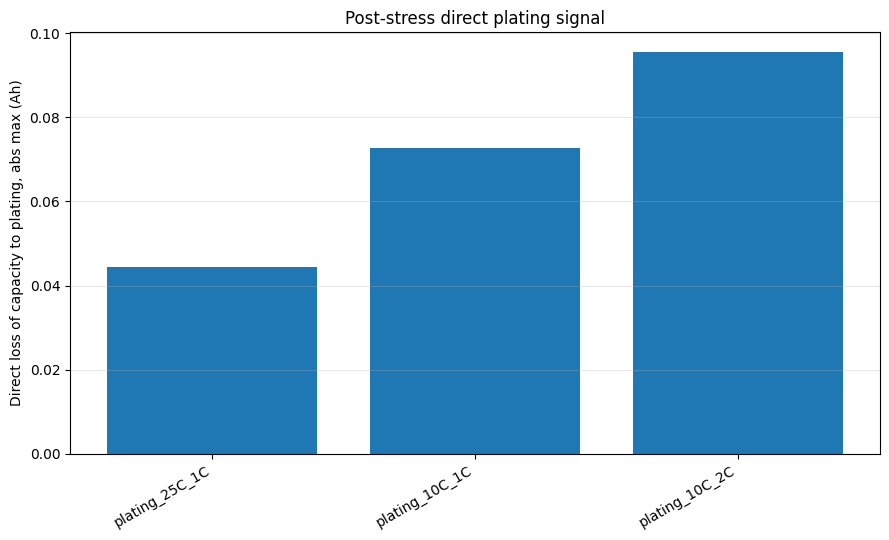

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_full_phaseA_direct_plating_capacity.png


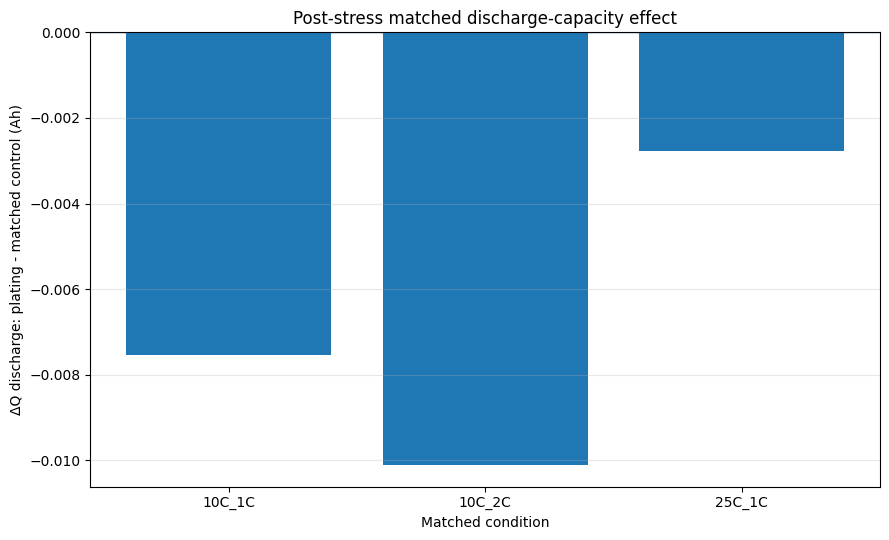

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_full_phaseA_matched_capacity_effect.png


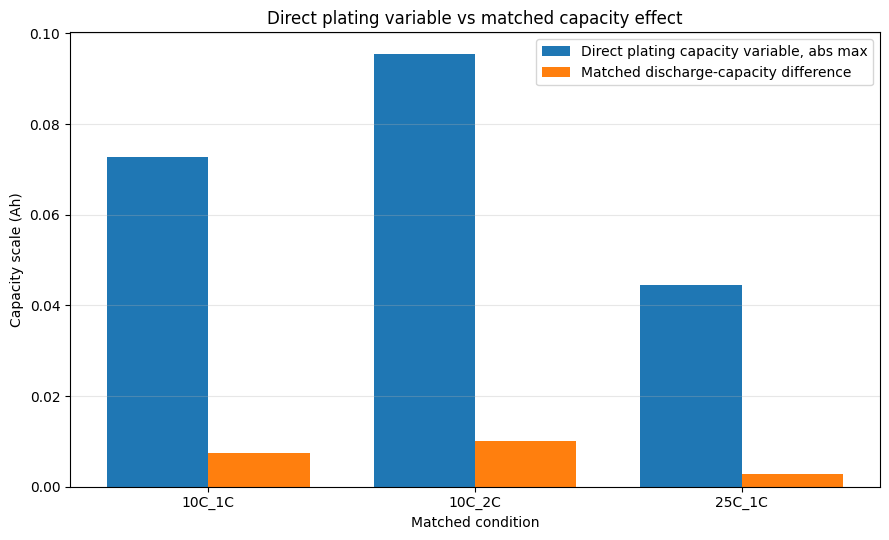

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_full_phaseA_direct_vs_capacity_effect.png
[OK] Phase A capacity audit and figures complete.


In [8]:
# Cell 8 — Matched capacity audit and Phase A figures
# （匹配容量审计与 Phase A 图像）

matched_capacity_rows = []

for pair, g in plating_full_capacity_table.groupby("pair"):
    control = g[g["plating_mode"] == "none"]
    plating = g[g["plating_mode"] != "none"]

    if len(control) != 1 or len(plating) != 1:
        raise RuntimeError(f"Pair {pair} does not have exactly one control and one plating condition.")

    control = control.iloc[0]
    plating = plating.iloc[0]

    delta_Ah = float(plating["Q_discharge_Ah"] - control["Q_discharge_Ah"])
    delta_pct = delta_Ah / float(control["Q_discharge_Ah"]) * 100

    obs = post_stress_observability_table[
        post_stress_observability_table["condition"] == plating["condition"]
    ].iloc[0]

    matched_capacity_rows.append({
        "pair": pair,
        "control_condition": control["condition"],
        "plating_condition": plating["condition"],
        "temperature_C": float(plating["temperature_C"]),
        "stress_charge_rate": plating["stress_charge_rate"],
        "control_Q_discharge_Ah": float(control["Q_discharge_Ah"]),
        "plating_Q_discharge_Ah": float(plating["Q_discharge_Ah"]),
        "delta_Q_discharge_plating_minus_control_Ah": delta_Ah,
        "delta_Q_discharge_plating_minus_control_pct": delta_pct,
        "direct_plating_capacity_abs_max_Ah": float(obs["loss_of_capacity_to_plating_Ah_abs_max"]),
        "direct_plating_current_density_abs_max_A_m2": float(obs["plating_current_density_A_m2_abs_max"]),
    })

plating_full_matched_capacity_audit = pd.DataFrame(matched_capacity_rows)

matched_cap_path = DATA / "plating_full_matched_capacity_audit.csv"
plating_full_matched_capacity_audit.to_csv(matched_cap_path, index=False)

print(f"[OK] saved: {matched_cap_path}")
display(plating_full_matched_capacity_audit)

# Figure 1 — direct plating signal
plt.figure(figsize=(9, 5.5))
plot_df = post_stress_observability_table[post_stress_observability_table["plating_mode"] != "none"].copy()
plt.bar(plot_df["condition"], plot_df["loss_of_capacity_to_plating_Ah_abs_max"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Direct loss of capacity to plating, abs max (Ah)")
plt.title("Post-stress direct plating signal")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
p = FIGURES / "plating_full_phaseA_direct_plating_capacity.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2 — matched capacity effect
plt.figure(figsize=(9, 5.5))
plt.bar(
    plating_full_matched_capacity_audit["pair"],
    plating_full_matched_capacity_audit["delta_Q_discharge_plating_minus_control_Ah"],
)
plt.axhline(0, linewidth=1)
plt.ylabel("ΔQ discharge: plating - matched control (Ah)")
plt.xlabel("Matched condition")
plt.title("Post-stress matched discharge-capacity effect")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
p = FIGURES / "plating_full_phaseA_matched_capacity_effect.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 3 — direct vs matched capacity effect
plt.figure(figsize=(9, 5.5))
x = np.arange(len(plating_full_matched_capacity_audit))
width = 0.38

plt.bar(
    x - width / 2,
    plating_full_matched_capacity_audit["direct_plating_capacity_abs_max_Ah"],
    width=width,
    label="Direct plating capacity variable, abs max",
)

plt.bar(
    x + width / 2,
    np.abs(plating_full_matched_capacity_audit["delta_Q_discharge_plating_minus_control_Ah"]),
    width=width,
    label="Matched discharge-capacity difference",
)

plt.xticks(x, plating_full_matched_capacity_audit["pair"])
plt.ylabel("Capacity scale (Ah)")
plt.xlabel("Matched condition")
plt.title("Direct plating variable vs matched capacity effect")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "plating_full_phaseA_direct_vs_capacity_effect.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

print("[OK] Phase A capacity audit and figures complete.")

In [2]:
# Cell 8A — Phase A classification and resource-boundary closure
# （Phase A 分类与资源边界收口，自包含版本）

from pathlib import Path
import pandas as pd
import numpy as np

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"

phaseA_obs_path = DATA / "plating_full_post_stress_observability_table.csv"
phaseA_capacity_path = DATA / "plating_full_capacity_table.csv"
phaseA_matched_path = DATA / "plating_full_matched_capacity_audit.csv"

required = [phaseA_obs_path, phaseA_capacity_path, phaseA_matched_path]

for p in required:
    if not p.exists():
        raise FileNotFoundError(f"Missing required Phase A file: {p}")

phaseA_obs = pd.read_csv(phaseA_obs_path)
phaseA_capacity = pd.read_csv(phaseA_capacity_path)
phaseA_matched = pd.read_csv(phaseA_matched_path)

control_clean = (
    phaseA_obs[phaseA_obs["plating_mode"] == "none"]
    ["any_direct_plating_signal_nonzero"]
    .eq(False)
    .all()
)

plating_detected = (
    phaseA_obs[phaseA_obs["plating_mode"] != "none"]
    ["any_direct_plating_signal_nonzero"]
    .eq(True)
    .all()
)

max_direct_plating_Ah = float(
    phaseA_matched["direct_plating_capacity_abs_max_Ah"].max()
)

max_current_density = float(
    phaseA_matched["direct_plating_current_density_abs_max_A_m2"].max()
)

max_matched_capacity_effect_Ah = float(
    phaseA_matched["delta_Q_discharge_plating_minus_control_Ah"].abs().max()
)

phaseA_classification_table = pd.DataFrame([
    {
        "metric_layer": "post_stress_direct_plating",
        "evidence": (
            f"Matched no-plating controls clean = {control_clean}; "
            f"plating-enabled branches detected = {plating_detected}."
        ),
        "strength": "strong" if control_clean and plating_detected else "limited",
        "classification": "direct plating observability is supported under matched controls",
    },
    {
        "metric_layer": "stress_sensitivity",
        "evidence": (
            f"Max direct plating capacity variable = {max_direct_plating_Ah:.6f} Ah; "
            f"max plating current density = {max_current_density:.6f} A/m²."
        ),
        "strength": "data-backed",
        "classification": "plating signal increases under low-temperature / high-rate stress",
    },
    {
        "metric_layer": "matched_capacity_effect",
        "evidence": (
            f"Max matched discharge-capacity effect = {max_matched_capacity_effect_Ah:.6f} Ah."
        ),
        "strength": "audit-level",
        "classification": "post-stress capacity effect is measurable but much smaller than direct plating variable",
    },
    {
        "metric_layer": "phaseB_resource_boundary",
        "evidence": (
            "In-notebook HPPC Phase B repeatedly caused kernel death under DFN + starting_solution + dense HPPC sampling."
        ),
        "strength": "execution boundary",
        "classification": "HPPC Ri(t) / relaxation audit deferred to process-isolated workflow",
    },
    {
        "metric_layer": "overall",
        "evidence": "Phase A completed: post-stress state, direct plating variables, matched capacity audit, and figures.",
        "strength": "supported",
        "classification": "plating full-fingerprint Phase A supported; full fingerprint remains deferred",
    },
])

phaseA_classification_path = DATA / "plating_full_phaseA_classification_table.csv"
phaseA_classification_table.to_csv(phaseA_classification_path, index=False)

print(f"[OK] saved: {phaseA_classification_path}")
display(phaseA_classification_table)


expected_outputs_phaseA = [
    DATA / "plating_full_branch_contract.csv",
    DATA / "plating_full_post_stress_observability_table.csv",
    DATA / "plating_full_capacity_segment_audit.csv",
    DATA / "plating_full_capacity_table.csv",
    DATA / "plating_full_matched_capacity_audit.csv",
    DATA / "plating_full_phaseA_classification_table.csv",

    FIGURES / "plating_full_phaseA_direct_plating_capacity.png",
    FIGURES / "plating_full_phaseA_matched_capacity_effect.png",
    FIGURES / "plating_full_phaseA_direct_vs_capacity_effect.png",
]

inventory_rows = []

for p in expected_outputs_phaseA:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

phaseA_output_inventory = pd.DataFrame(inventory_rows)

inventory_path = DATA / "plating_full_phaseA_output_inventory.csv"
phaseA_output_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(phaseA_output_inventory)

assert phaseA_output_inventory["exists"].all(), "Some Phase A expected outputs are missing."

print("[OK] Phase A output inventory complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_full_phaseA_classification_table.csv


,metric_layer,evidence,strength,classification
0,post_stress_direct_plating,Matched no-plating controls clean = True; plat...,strong,direct plating observability is supported unde...
1,stress_sensitivity,Max direct plating capacity variable = 0.09544...,data-backed,plating signal increases under low-temperature...
2,matched_capacity_effect,Max matched discharge-capacity effect = 0.0101...,audit-level,post-stress capacity effect is measurable but ...
3,phaseB_resource_boundary,In-notebook HPPC Phase B repeatedly caused ker...,execution boundary,HPPC Ri(t) / relaxation audit deferred to proc...
4,overall,"Phase A completed: post-stress state, direct p...",supported,plating full-fingerprint Phase A supported; fu...


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_full_phaseA_output_inventory.csv


,path,exists,size_kB
0,data/plating_full_branch_contract.csv,True,0.52
1,data/plating_full_post_stress_observability_ta...,True,8.12
2,data/plating_full_capacity_segment_audit.csv,True,4.29
3,data/plating_full_capacity_table.csv,True,1.13
4,data/plating_full_matched_capacity_audit.csv,True,0.77
5,data/plating_full_phaseA_classification_table.csv,True,1.00
6,figures/plating_full_phaseA_direct_plating_cap...,True,100.56
7,figures/plating_full_phaseA_matched_capacity_e...,True,95.72
8,figures/plating_full_phaseA_direct_vs_capacity...,True,104.74


[OK] Phase A output inventory complete.


In [3]:
# Cell 8A — Phase A classification and resource-boundary closure
# （Phase A 分类与资源边界收口）

phaseA_obs = pd.read_csv(DATA / "plating_full_post_stress_observability_table.csv")
phaseA_capacity = pd.read_csv(DATA / "plating_full_capacity_table.csv")
phaseA_matched = pd.read_csv(DATA / "plating_full_matched_capacity_audit.csv")

control_clean = (
    phaseA_obs[phaseA_obs["plating_mode"] == "none"]
    ["any_direct_plating_signal_nonzero"]
    .eq(False)
    .all()
)

plating_detected = (
    phaseA_obs[phaseA_obs["plating_mode"] != "none"]
    ["any_direct_plating_signal_nonzero"]
    .eq(True)
    .all()
)

max_direct_plating_Ah = float(
    phaseA_matched["direct_plating_capacity_abs_max_Ah"].max()
)

max_current_density = float(
    phaseA_matched["direct_plating_current_density_abs_max_A_m2"].max()
)

max_matched_capacity_effect_Ah = float(
    phaseA_matched["delta_Q_discharge_plating_minus_control_Ah"].abs().max()
)

phaseA_classification_table = pd.DataFrame([
    {
        "metric_layer": "post_stress_direct_plating",
        "evidence": (
            f"Matched no-plating controls clean = {control_clean}; "
            f"plating-enabled branches detected = {plating_detected}."
        ),
        "strength": "strong" if control_clean and plating_detected else "limited",
        "classification": "direct plating observability is supported under matched controls",
    },
    {
        "metric_layer": "stress_sensitivity",
        "evidence": (
            f"Max direct plating capacity variable = {max_direct_plating_Ah:.6f} Ah; "
            f"max plating current density = {max_current_density:.6f} A/m²."
        ),
        "strength": "data-backed",
        "classification": "plating signal increases under low-temperature / high-rate stress",
    },
    {
        "metric_layer": "matched_capacity_effect",
        "evidence": (
            f"Max matched discharge-capacity effect = {max_matched_capacity_effect_Ah:.6f} Ah."
        ),
        "strength": "audit-level",
        "classification": "post-stress capacity effect is measurable but much smaller than direct plating variable",
    },
    {
        "metric_layer": "phaseB_resource_boundary",
        "evidence": (
            "In-notebook HPPC Phase B repeatedly caused kernel death under DFN + starting_solution + dense HPPC sampling."
        ),
        "strength": "execution boundary",
        "classification": "HPPC Ri(t) / relaxation audit deferred to process-isolated workflow",
    },
    {
        "metric_layer": "overall",
        "evidence": "Phase A completed: post-stress state, direct plating variables, matched capacity audit, and figures.",
        "strength": "supported",
        "classification": "plating full-fingerprint Phase A supported; full fingerprint remains deferred",
    },
])

phaseA_classification_path = DATA / "plating_full_phaseA_classification_table.csv"
phaseA_classification_table.to_csv(phaseA_classification_path, index=False)

print(f"[OK] saved: {phaseA_classification_path}")
display(phaseA_classification_table)


expected_outputs_phaseA = [
    DATA / "plating_full_branch_contract.csv",
    DATA / "plating_full_post_stress_observability_table.csv",
    DATA / "plating_full_capacity_segment_audit.csv",
    DATA / "plating_full_capacity_table.csv",
    DATA / "plating_full_matched_capacity_audit.csv",
    DATA / "plating_full_phaseA_classification_table.csv",

    FIGURES / "plating_full_phaseA_direct_plating_capacity.png",
    FIGURES / "plating_full_phaseA_matched_capacity_effect.png",
    FIGURES / "plating_full_phaseA_direct_vs_capacity_effect.png",
]

inventory_rows = []

for p in expected_outputs_phaseA:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

phaseA_output_inventory = pd.DataFrame(inventory_rows)

inventory_path = DATA / "plating_full_phaseA_output_inventory.csv"
phaseA_output_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(phaseA_output_inventory)

assert phaseA_output_inventory["exists"].all(), "Some Phase A expected outputs are missing."

print("[OK] Phase A output inventory complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_full_phaseA_classification_table.csv


,metric_layer,evidence,strength,classification
0,post_stress_direct_plating,Matched no-plating controls clean = True; plat...,strong,direct plating observability is supported unde...
1,stress_sensitivity,Max direct plating capacity variable = 0.09544...,data-backed,plating signal increases under low-temperature...
2,matched_capacity_effect,Max matched discharge-capacity effect = 0.0101...,audit-level,post-stress capacity effect is measurable but ...
3,phaseB_resource_boundary,In-notebook HPPC Phase B repeatedly caused ker...,execution boundary,HPPC Ri(t) / relaxation audit deferred to proc...
4,overall,"Phase A completed: post-stress state, direct p...",supported,plating full-fingerprint Phase A supported; fu...


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_full_phaseA_output_inventory.csv


,path,exists,size_kB
0,data/plating_full_branch_contract.csv,True,0.52
1,data/plating_full_post_stress_observability_ta...,True,8.12
2,data/plating_full_capacity_segment_audit.csv,True,4.29
3,data/plating_full_capacity_table.csv,True,1.13
4,data/plating_full_matched_capacity_audit.csv,True,0.77
5,data/plating_full_phaseA_classification_table.csv,True,1.00
6,figures/plating_full_phaseA_direct_plating_cap...,True,100.56
7,figures/plating_full_phaseA_matched_capacity_e...,True,95.72
8,figures/plating_full_phaseA_direct_vs_capacity...,True,104.74


[OK] Phase A output inventory complete.


## Final closure — Notebook 26 Phase A

### Key findings

Notebook 26 was intended to extend plating entry observability into a full lithium plating（析锂）fingerprint audit.

Phase A was completed successfully. It covered:

1. post-stress state generation（应力后状态生成）,
2. direct plating-state observability（直接析锂状态可观测性）,
3. Capacity RPT（容量基准性能测试） from post-stress states,
4. matched capacity-effect audit（匹配容量效应审计）,
5. Phase A visualization.

### Phase A result

Matched no-plating controls remained clean:

- no_plating_25C_1C: direct plating signal = False,
- no_plating_10C_1C: direct plating signal = False,
- no_plating_10C_2C: direct plating signal = False.

Plating-enabled branches showed direct plating signals:

- plating_25C_1C: direct plating signal = True,
- plating_10C_1C: direct plating signal = True,
- plating_10C_2C: direct plating signal = True.

The direct plating signal increased with stress severity.

Direct loss-of-capacity-to-plating, absolute maximum:

- plating_25C_1C: ≈ 0.0445 Ah,
- plating_10C_1C: ≈ 0.0728 Ah,
- plating_10C_2C: ≈ 0.0954 Ah.

Matched post-stress discharge-capacity differences were much smaller:

- 25C_1C: approximately −0.00276 Ah,
- 10C_1C: approximately −0.00753 Ah,
- 10C_2C: approximately −0.01011 Ah.

This confirms the same interpretation boundary established in Notebook 25:

`direct plating variable peak ≠ final irreversible capacity loss`

The plating model is partially reversible（部分可逆析锂）, so part of the plated lithium can be stripped or recovered during later protocol stages.

### Phase B resource boundary

Phase B attempted to extend the audit to HPPC Ri(t)（时间窗内阻） and corrected relaxation descriptors（修正后恢复描述符）.

However, repeated in-notebook execution of DFN + SEI-background plating + `starting_solution` + dense HPPC sampling caused Jupyter kernel death.

This is treated as an execution-resource boundary, not as a scientific failure.

The affected layer is therefore classified as:

`HPPC Ri(t) / relaxation under plating = deferred`

A process-isolated workflow is required for this branch.

### Correct conclusion wording

Supported:

- SEI-background plating post-stress states are runnable.
- Direct negative-electrode plating variables are observable.
- Matched no-plating controls remain clean.
- Plating-enabled branches show stress-sensitive direct plating signals.
- Matched post-stress capacity effects are measurable but smaller than direct plating-variable peaks.

Not supported:

- Notebook 26 does not complete the full plating fingerprint.
- HPPC Ri(t) and relaxation descriptors under plating were not successfully audited inside this notebook.
- Direct plating variables must not be equated with final irreversible capacity loss.
- The full Mechanism Fingerprint Registry v0.2 row for plating remains incomplete.

### Project-level classification

`plating full-fingerprint Phase A = supported`

`full plating fingerprint = still deferred`

Project-level wording:

> Phase A confirms that post-stress SEI-background plating states are directly observable and matched-capacity effects are measurable. However, the HPPC Ri(t) and relaxation layer triggered a Jupyter/PyBaMM resource boundary and must be moved to a process-isolated workflow before plating can be included in the final cross-mechanism fingerprint synthesis.

### Next step

The next task should not be another in-notebook HPPC attempt.

Recommended next step:

`26B_plating_hppc_process_isolated_audit`

Implementation principle:

- run one condition per external Python process,
- write one descriptor CSV per condition,
- merge descriptors only after all processes complete,
- avoid storing large PyBaMM Solution objects in Jupyter memory.

Only after this process-isolated HPPC audit succeeds should the project continue to C/25 V(Q), GITT-like finite-rest, and ICA/DVA under plating.